In [51]:
#Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots in notebook
%matplotlib inline

# Set seaborn style
sns.set_style('whitegrid')

In [52]:
#Step 2: Load the Datasets
# Load Air Quality dataset
air_quality = pd.read_csv('AirQualityUCI.csv',sep=';',decimal=',')

# Load Heart Disease dataset
heart_disease = pd.read_csv('heartdisease.csv')

# Display first 5 rows
print("Air Quality Dataset")
display(air_quality.head())

print("Heart Disease Dataset")
display(heart_disease.head())

Air Quality Dataset


,"Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),Wind,PT08.S2(NMHC),Solor.R,PT08.S3(NOx),NO2(GT),PT08.S4(NO2),Ozone,Temp,RH,AH"
0,"10-03-2004,18:00:00,2.6,1360,150,11.9,1046,166..."
1,"10-03-2004,19:00:00,2,1292,112,9.4,955,103,117..."
2,"10-03-2004,20:00:00,2.2,1402,88,9,939,131,1140..."
3,"10-03-2004,21:00:00,2.2,1376,80,9.2,948,172,10..."
4,"10-03-2004,22:00:00,1.6,1272,51,6.5,836,131,12..."


Heart Disease Dataset


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [53]:
#Step 3: Understand the Dataset
# Remove empty columns
air_quality = air_quality.dropna(axis=1, how='all')

# Replace missing values
air_quality.replace(-200, np.nan, inplace=True)

# Convert numeric columns
for col in air_quality.columns:
    
    # Skip Date and Time columns
    if col not in ['Date', 'Time']:
        
        air_quality[col] = pd.to_numeric(
            air_quality[col],
            errors='coerce'
        )

# Check data types
print(air_quality.dtypes)

print("\nHeart Disease Dataset Info")
heart_disease.info()

Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),Wind,PT08.S2(NMHC),Solor.R,PT08.S3(NOx),NO2(GT),PT08.S4(NO2),Ozone,Temp,RH,AH    float64
dtype: object

Heart Disease Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  num       303 non-null    int64  
dtypes: float64(1), int64(11), str(2)
memory usage: 33.3 KB


In [54]:
#Step 4: Check Missing Values
print("Missing values in Air Quality Dataset")
print(air_quality.isnull().sum())

print("\nMissing values in Heart Disease Dataset")
print(heart_disease.isnull().sum())

Missing values in Air Quality Dataset
Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),Wind,PT08.S2(NMHC),Solor.R,PT08.S3(NOx),NO2(GT),PT08.S4(NO2),Ozone,Temp,RH,AH    9357
dtype: int64

Missing values in Heart Disease Dataset
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [57]:


##Select Numeric Columns
aq_numeric = air_quality.select_dtypes(include=np.number)

print(aq_numeric.head())

   Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),Wind,PT08.S2(NMHC),Solor.R,PT08.S3(NOx),NO2(GT),PT08.S4(NO2),Ozone,Temp,RH,AH
0                                                NaN                                                                  
1                                                NaN                                                                  
2                                                NaN                                                                  
3                                                NaN                                                                  
4                                                NaN                                                                  


In [58]:
#Step 6: Statistical Summary
print("Air Quality Summary")
display(air_quality.describe())

print("Heart Disease Summary")
display(heart_disease.describe())

Air Quality Summary


,"Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),Wind,PT08.S2(NMHC),Solor.R,PT08.S3(NOx),NO2(GT),PT08.S4(NO2),Ozone,Temp,RH,AH"
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


Heart Disease Summary


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


In [59]:
#replacement for string
# Replace '?' with NaN
heart_disease = heart_disease.replace('?', np.nan)

# Convert all columns to numeric where possible
heart_disease = heart_disease.apply(pd.to_numeric, errors='coerce')

# Check data types
print(heart_disease.dtypes)

# Select only numeric columns
heart_numeric = heart_disease.select_dtypes(include=np.number)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object


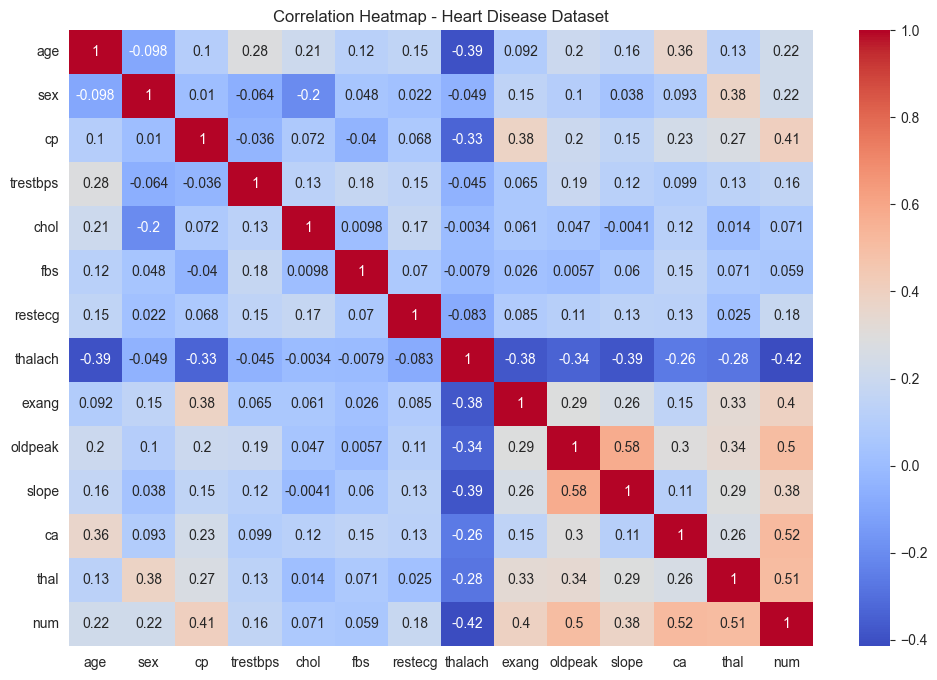

In [60]:
#Step 7: Correlation Heatmap (Heart Disease Dataset)
plt.figure(figsize=(12,8))

sns.heatmap(
    heart_numeric.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap - Heart Disease Dataset')

plt.show()

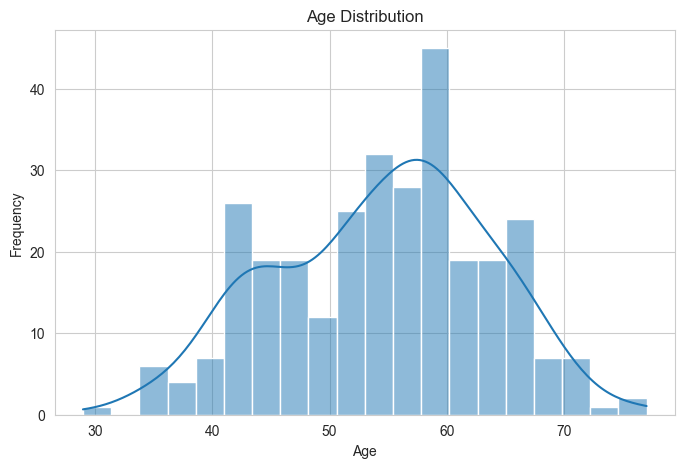

In [61]:
#Step 8: Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    heart_disease['age'],
    bins=20,
    kde=True
)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

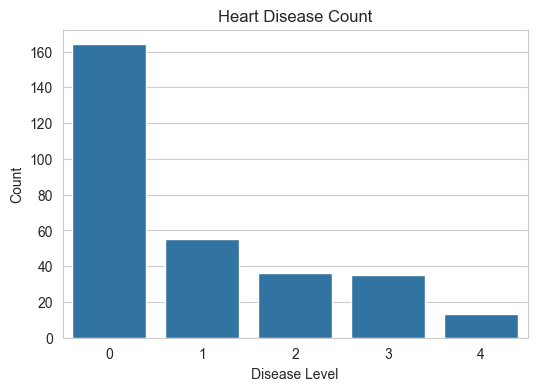

In [62]:
# disease vs count
plt.figure(figsize=(6,4))

sns.countplot(
    x='num',
    data=heart_disease
)

plt.title('Heart Disease Count')
plt.xlabel('Disease Level')
plt.ylabel('Count')

plt.show()

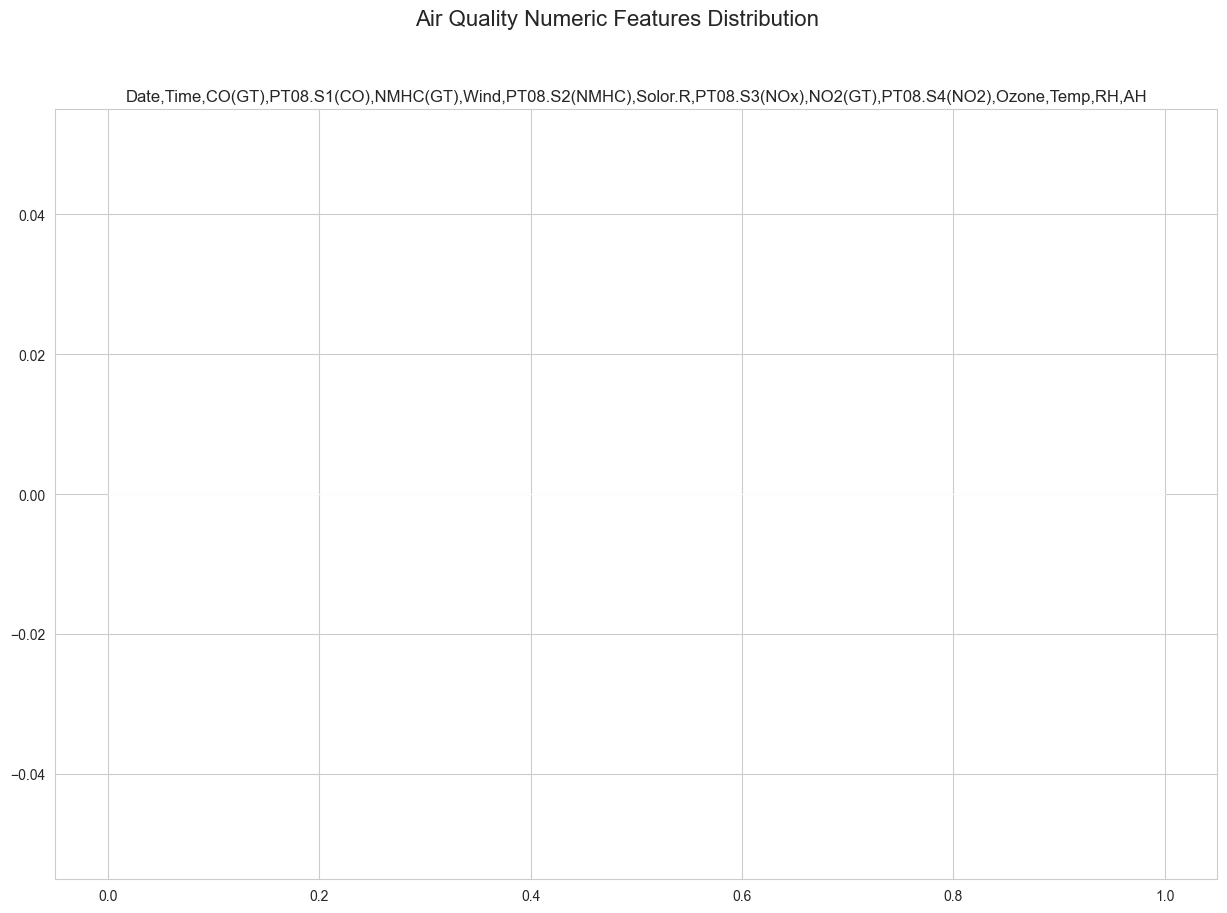

In [64]:
#Step 12: Air Quality Numeric Feature Distribution
aq_numeric.hist(figsize=(15,10))

plt.suptitle(
    'Air Quality Numeric Features Distribution',
    fontsize=16
)

plt.show()

C:\Users\sanil\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\sanil\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


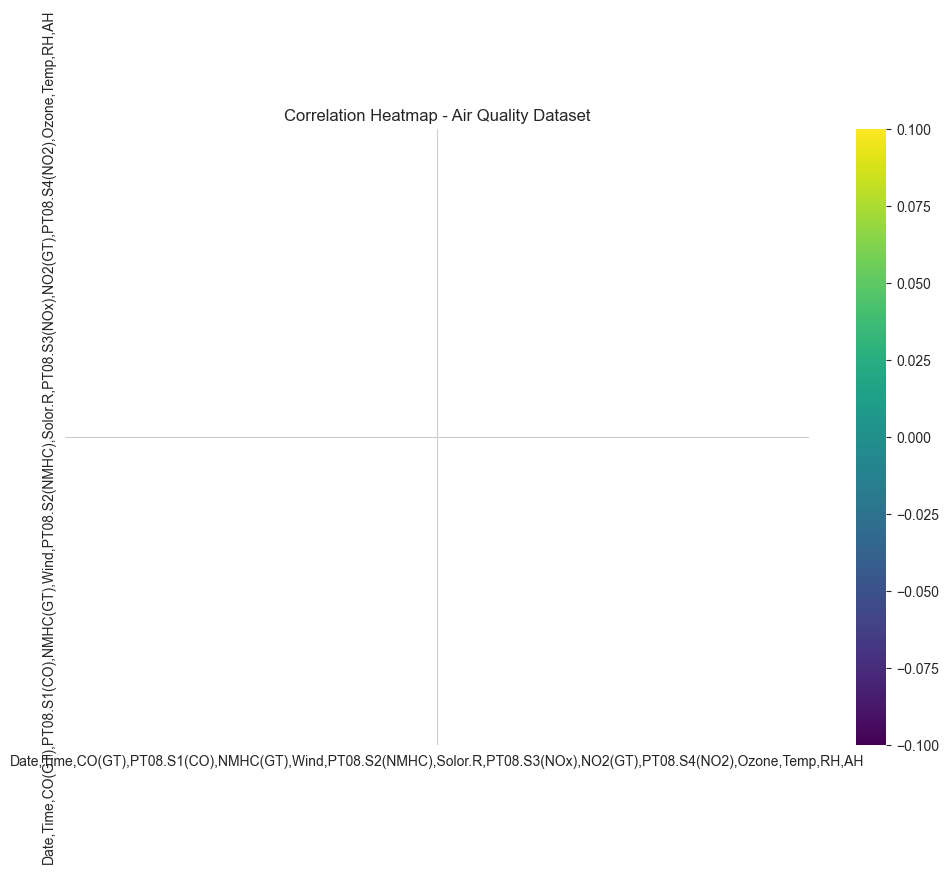

In [65]:
# air quality Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    aq_numeric.corr(),
    cmap='viridis',
    annot=False
)

plt.title('Correlation Heatmap - Air Quality Dataset')

plt.show()

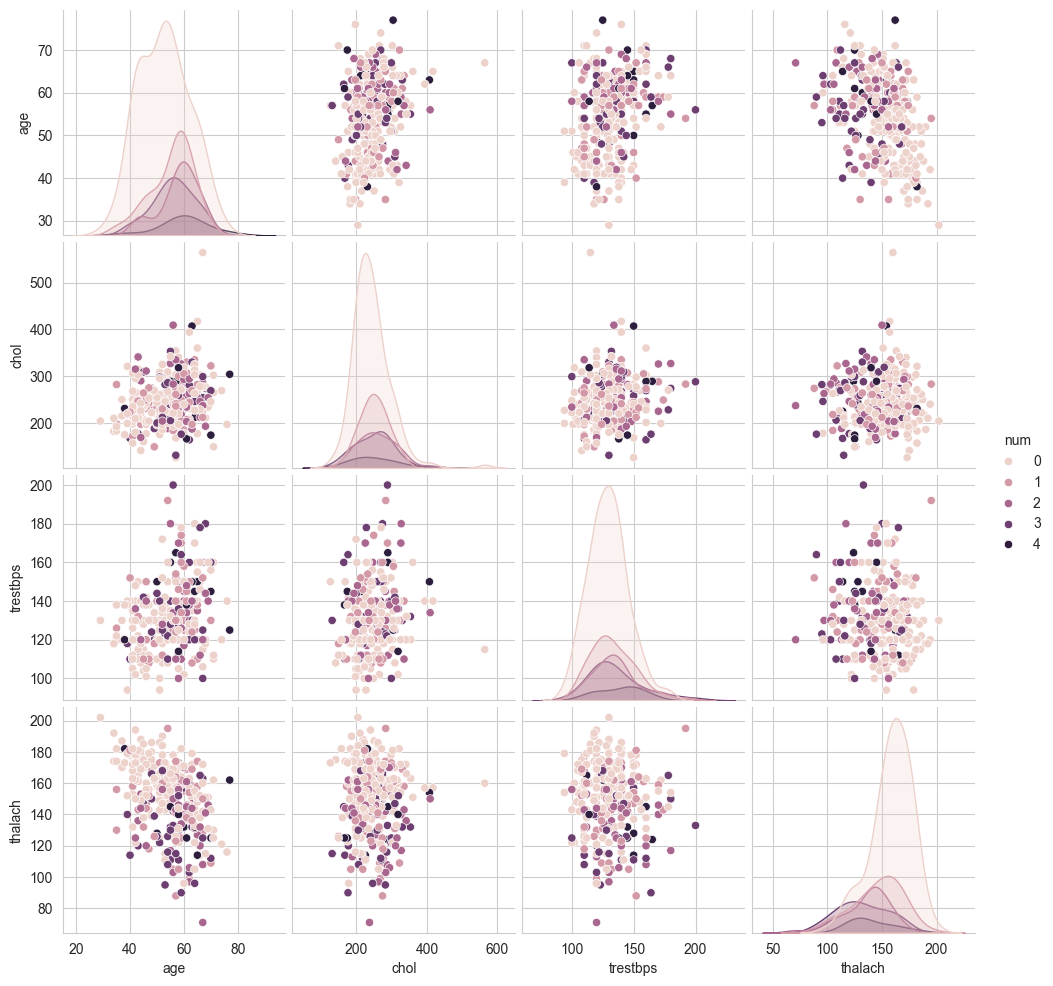

In [29]:
sns.pairplot(
    heart_disease[['age','chol','trestbps','thalach','num']],
    hue='num'
)

plt.show()